### Co-purchasing analysis
Here we use a financial marketing dataset:

> Amazon product co-purchasing network and ground-truth communities
> 
> J. Yang and J. Leskovec. Defining and Evaluating Network Communities based on Ground-truth. ICDM, 2012.

To evaluate how the cluster of items (communities) can grow through the co-purchasing behavior of customers. 


In [21]:
import numpy as np
import scipy.sparse as sp
import warnings
# Suppress specific TqdmWarning related to IProgress
warnings.filterwarnings("ignore", category=UserWarning, module="tqdm")
from copurchase_data_process import read_adjacent_mat, \
    read_label,build_feature_vectors,preprocess_graph

%reload_ext autoreload
%autoreload 2

adj = read_adjacent_mat("data/co-purchasing/graph.txt")
NODES_NUM = adj.shape[0]
labels, train_mask, test_mask = \
    read_label("data/co-purchasing/cmty5000.txt",\
    NODES_NUM,
    class_num = 250,
    class_max_rate = 0.8,
    class_max_samp = 0,
    missing_class = 0)

CLASS_NUM = np.max(labels) # zero is unknown class. No ground truth.

labels = labels - 1 # 0-based index so that the cross entropy loss work correct.
# see some line of the adj matrix,check whether it is correct
print("Edge Connect to The First Node :",adj[0].sum())
print("Node Number: ",NODES_NUM)
print("Label Number: ", CLASS_NUM)
print("Train Node Number: ",np.sum(train_mask))   
print("Test Node Number: ",np.sum(test_mask))
print("Adjacent matrix shape: ", adj.shape)
# preprocess the graph (every time it is random, so need to serialize into file)
adj,labels,train_mask,test_mask,id_list = preprocess_graph(adj,labels,train_mask,test_mask,\
    keep_percent=0.25)
NODES_NUM = adj.shape[0]
print("Node number after preprocess: ",NODES_NUM)
# Save to .npz file
np.savez('data/co-purchasing/graph_data.npz',adj=adj, labels=labels, train_mask=train_mask, test_mask=test_mask,id_list = id_list)

Items belongs to the first class:  214
Items belongs to the last class:  27
Edge Connect to The First Node : 8
Node Number:  334863
Label Number:  250
Train Node Number:  2305
Test Node Number:  625
Adjacent matrix shape:  (334863, 334863)
Remove nodes:  248979
Remove isolated nodes:  26571
Node number after preprocess:  59313


In [22]:
# only use adjacent matrix to generate feature vectors
features_adj = build_feature_vectors(adj, NODES_NUM,dimensions=500)
print("Feature Shape: ",features_adj.shape)

# save this feature matrix to disk, so that we can use it in the future.
np.save("data/co-purchasing/features.npy",features_adj)

Trainslate to networkx graph


Computing transition probabilities:   0%|          | 0/59313 [00:00<?, ?it/s]

Build Node2Vec model
Finish feature random walk
Extract the features out
Feature Shape:  (59313, 500)


In [1]:
from train import train_fc,train_base
from scipy.sparse import coo_matrix
import torch
import numpy as np
# read graph data
data = np.load("data/co-purchasing/graph_data.npz",allow_pickle=True)
labels = data['labels']
NODES_NUM = len(labels)
adj = coo_matrix(data['adj'].tolist(),shape=(NODES_NUM,NODES_NUM)).tocsr()
train_mask = data['train_mask']
test_mask = data['test_mask']
id_list = data['id_list']
# read the feature matrix from disk
CLASS_NUM = np.max(labels)+1
FEATURE_NUM = 2000
torch.cuda.empty_cache()
features_adj = np.load("data/co-purchasing/features.npy",allow_pickle=True).tolist()
features_adj = coo_matrix(features_adj,shape=(NODES_NUM,FEATURE_NUM))
print("Original ID list: ",id_list)

Original ID list:  [     5     35     39 ... 334841 334844 334858]


In [22]:
# this is memory consuming and not very well
layer_dims = [features_adj.shape[1], 500, CLASS_NUM]
#print("Layer dimensions: ", layer_dims)
print(features_adj.shape,adj.shape,labels.shape)
base_model, train_acc_list,test_acc_list, loss_list ,predict_result = train_base(
    layer_dims=layer_dims,
    data=(adj, features_adj, labels, train_mask , test_mask),
    dropout_rate=0.3,
    learning_rate= 0.001,
    weight_decay=  5e-4,
    self_importance= 1.0,
    epoch_num = 60,
)
# non_zero_num = base_model.layers[0].input_nonezero_num
# torch.save(base_model.state_dict(), "data/co-purchasing/base_model.pth")

(44217, 500) (44217, 44217) (44217,)
Using device: cuda 
layer_dims: [500, 500, 500], 
dropout_rate: 0.3, 
learning_rate: 0.001, 
weight_decay: 0.0005, 
epoch_num: 60, 
self_importance: 1.0, 
laplace_norm: True
Epoch: 0, Loss: 6.4640, Train Set Acc: 0.0064, Validate Set Acc: 0.0043
Epoch: 1, Loss: 6.4551, Train Set Acc: 0.0042, Validate Set Acc: 0.0064
Epoch: 2, Loss: 6.4458, Train Set Acc: 0.0089, Validate Set Acc: 0.0085
Epoch: 3, Loss: 6.4376, Train Set Acc: 0.0097, Validate Set Acc: 0.0107
Epoch: 4, Loss: 6.4289, Train Set Acc: 0.0110, Validate Set Acc: 0.0107
Epoch: 5, Loss: 6.4210, Train Set Acc: 0.0127, Validate Set Acc: 0.0064
Epoch: 6, Loss: 6.4126, Train Set Acc: 0.0131, Validate Set Acc: 0.0192
Epoch: 7, Loss: 6.4042, Train Set Acc: 0.0157, Validate Set Acc: 0.0107
Epoch: 8, Loss: 6.3964, Train Set Acc: 0.0140, Validate Set Acc: 0.0192
Epoch: 9, Loss: 6.3885, Train Set Acc: 0.0195, Validate Set Acc: 0.0171
Epoch: 10, Loss: 6.3820, Train Set Acc: 0.0148, Validate Set Acc: 0.0

In [25]:
# use SGC here, a better solution for large graph.
from train import train_sgc
# id_feature = identity_matrix = sp.identity(NODES_NUM, format='csr')
layer_dims = [features_adj.shape[1], CLASS_NUM]
sgc_model, train_acc_list,test_acc_list, loss_list ,predict_result = train_sgc(
    layer_dims=layer_dims,
    data=(adj, features_adj, labels, train_mask , test_mask),
    degree = 7,
    learning_rate= 0.01,
    weight_decay=  9e-4,
    self_importance= 1,
    epoch_num = 85,
)
# save the model and the predict result to disk
torch.save(sgc_model.state_dict(), "data/co-purchasing/sgc_model.pth")
np.save("data/co-purchasing/sgc_predict_result.npy",predict_result)

Using device: cuda 
layer_dims: [500, 250], 
dropout_rate: 0, 
learning_rate: 0.01, 
weight_decay: 0.0009, 
epoch_num: 85, 
self_importance: 1, 
laplace_norm: True
Epoch: 0, Loss: 27.0008, Train Set Acc: 0.0513, Validate Set Acc: 0.0085
Epoch: 1, Loss: 15.3549, Train Set Acc: 0.0960, Validate Set Acc: 0.0283
Epoch: 2, Loss: 14.8403, Train Set Acc: 0.1002, Validate Set Acc: 0.0142
Epoch: 3, Loss: 13.9904, Train Set Acc: 0.1234, Validate Set Acc: 0.0170
Epoch: 4, Loss: 12.5812, Train Set Acc: 0.1473, Validate Set Acc: 0.0170
Epoch: 5, Loss: 11.8600, Train Set Acc: 0.1604, Validate Set Acc: 0.0170
Epoch: 6, Loss: 11.5148, Train Set Acc: 0.1670, Validate Set Acc: 0.0142
Epoch: 7, Loss: 10.8984, Train Set Acc: 0.1920, Validate Set Acc: 0.0142
Epoch: 8, Loss: 10.3905, Train Set Acc: 0.2129, Validate Set Acc: 0.0227
Epoch: 9, Loss: 9.8831, Train Set Acc: 0.2326, Validate Set Acc: 0.0283
Epoch: 10, Loss: 9.1726, Train Set Acc: 0.2522, Validate Set Acc: 0.0312
Epoch: 11, Loss: 8.6033, Train Set

In [3]:
from visualize import embedding_to_2d, plot_cluster, plot_acc_loss,plot_graph
node_embeddings_2d = None

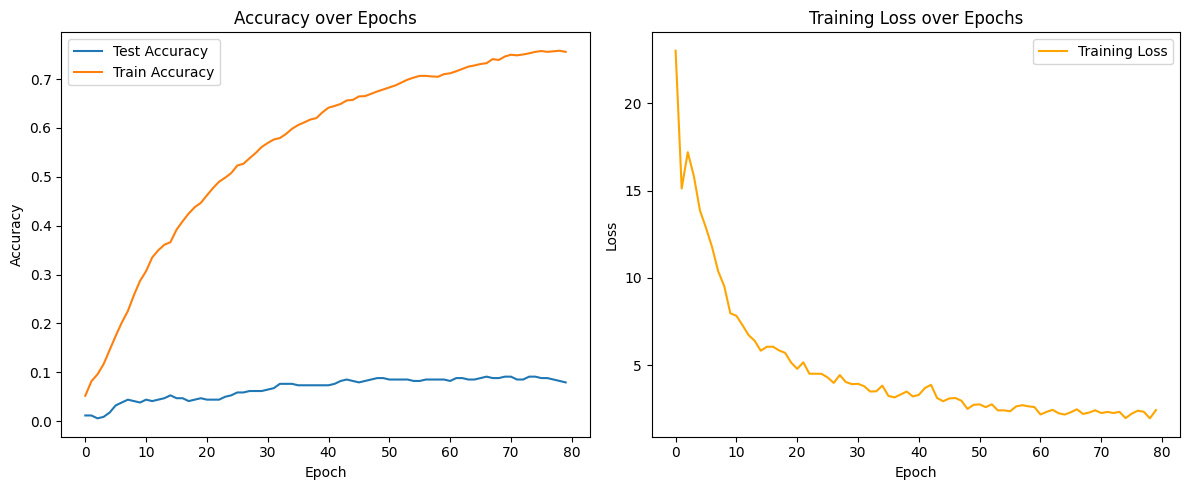

In [7]:
import matplotlib.pyplot as plt
# 绘制验证准确率曲线
plot_acc_loss(test_acc_list, train_acc_list, loss_list)

In [12]:
predict_result = np.load("data/co-purchasing/sgc_predict_result.npy")
recomm_class = id_list[np.where(predict_result==5)[0]][:10]
print("Recommendation class: ",recomm_class.shape[0])
# open amazon-meta.txt to get the product name
with open("data/co-purchasing/amazon-meta.txt","r") as f:
    is_target = False
    for line in f:
        if line.startswith("Id:"):
            current_id = int(line.split("Id:")[1].strip())
            if current_id in recomm_class:
                is_target = True
                print(line)
        elif is_target:
            if line.startswith("  title:"):
                print(line)
            if line.startswith("  group:"):
                print(line)
                is_target = False


Recommendation class:  10
Id:   39

  title: Night of Many Dreams : A Novel

  group: Book

Id:   330

  title: Logan's Search (Logan Series, 3rd Book)

  group: Book

Id:   651

  title: A Winter's Solstice, Vol. 6

  group: Music

Id:   1822

  title: Cordina's Crown Jewel

  group: Book

Id:   1973

  title: Tibili: The Little Boy Who Didn't Want to Go to School

  group: Book

Id:   1974

  title: The Joy of Pi

  group: Book

Id:   1975

  title: The Fastest Way To Get Pregnant Naturally

  group: Book

Id:   1978

  title: Come on Christmas

  group: Music

Id:   2113

  title: Dantes' Inferno: A Dr. Sylvia Strange Novel

  group: Book

Id:   2195

  title: Coldheart Canyon: A Hollywood Ghost Story

  group: Book



node number to plot:  2004


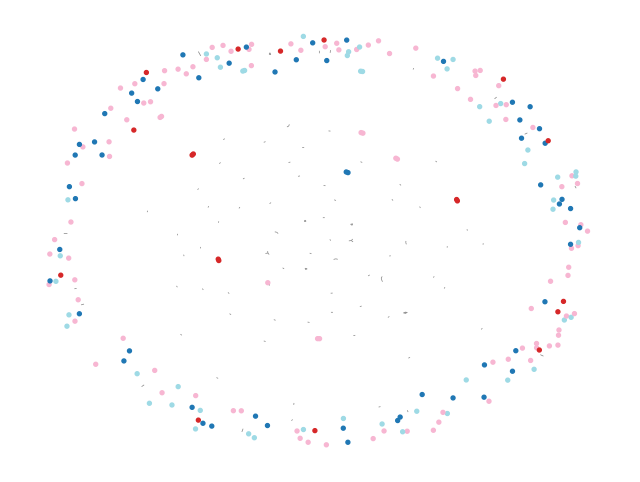

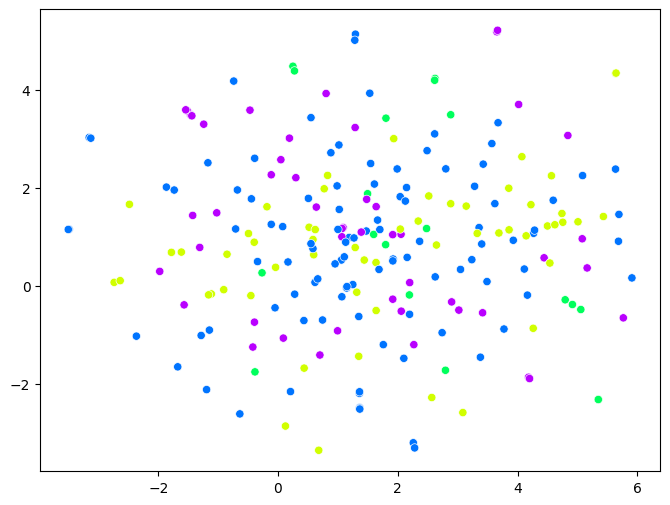

In [8]:
# select only the node that train_mask and test_mask is true
# only draw top five class
combined_mask = np.where((train_mask + test_mask))[0]
select_labels = predict_result[combined_mask]

select_features = features_adj.todense()[combined_mask]
# trainslate coor matrix to sparse matrix
select_adj = adj[combined_mask][:, combined_mask]

no_plot_mask = ~np.isin(select_labels,[0,1,2,3,4])
select_labels[no_plot_mask] = -1
print("node number to plot: ",len(select_labels))
plot_graph(select_adj, select_labels)

select_labels1 = np.delete(select_labels, np.where(select_labels == -1))
select_features1 = np.delete(select_features, np.where(select_labels == -1),axis=0)

node_embeddings_2d = embedding_to_2d(select_features1, feature_num=212)
plot_cluster(node_embeddings_2d,select_labels1)
